# From ECG to HR and simple HRV (Principles: vagal tone, RSA)

## TODOs

1. Compute RMSSD and HF power during baseline vs stress masks. 
2. Describe which increases/decreases and why (vagal withdrawal during stress → lower RMSSD/HF).

## My notes

+ RMSSD (Root Mean Square of Successive Differences)
    - Calculate using the R-peaks, where these R-peaks are the heartbeats.
    - R-peaks come from ECG, where ECG has P-wave, QRS-complex, and T-wave.
    - Time domain.
    - Steps:
        1. From the ECG, detect the components: P-wave, QRS-complex, and T-wave. 
        2. Delineate ECG for R-peaks, where these R-peaks are the heartbeats
        3. Calculate RMSSD by passing in R-peaks to get HRV
            - 3.1 1 R-peak = 1 Heartbeat
            - 3.2 Consecutive R-peaks are RR-interval = consecutive HBs
                - 3.2.1  From RR-interval, calculate LF/HF
    - We want this value to be
        1. high bc it leads to better recovery + more ANS stimulaton?
            - high means more time between heartbeats
        2. varied bc it leads to better recovery
+ HF (High Frequency) power
    1. Frequency domain.
    2. Favors parasympathetic activity, which is rest and recovery/digest.
    3. We want this value to be high bc...

## Code

In [1]:
import os
import pickle

import numpy as np
import pandas as pd

import neurokit2 as nk

import matplotlib.pyplot as plt

from tqdm import tqdm

from scipy.interpolate import interp1d
from scipy.signal import find_peaks, welch
from adtk.data import validate_series
from adtk.detector import ThresholdAD

notebook_dir = os.getcwd()

## Load Data

In [2]:
ecg_sampling_rate = 700

In [3]:
data_path = os.path.join(notebook_dir, "../../../data/WESAD/all_subjects/chest.csv")
df = pd.read_csv(data_path)
df.drop(['Unnamed: 0'], axis=1, inplace=True)
df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,0.9554,-0.2220,-0.5580,0.021423,-0.004440,5.250549,30.120758,-1.148987,S2,0
1,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,S2,0
2,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,S2,0
3,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,S2,0
4,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.130950,-1.161194,S2,0
...,...,...,...,...,...,...,...,...,...,...
60807595,0.9006,-0.0400,-0.1898,0.173676,-0.005539,7.265091,33.862762,0.318909,S17,0
60807596,0.9022,-0.0398,-0.1872,0.168777,-0.004944,7.266617,33.859740,0.233459,S17,0
60807597,0.9028,-0.0424,-0.1864,0.167130,-0.016068,7.262802,33.864290,0.318909,S17,0
60807598,0.9002,-0.0408,-0.1854,0.170334,0.005173,7.269669,33.862762,0.308228,S17,0


In [4]:
def get_per_subject(df):
    per_subject = {}
    entries = df['subject'].unique()
    for entry in entries:
        filt_subject = (df['subject'] == entry)
        subject_df = df[filt_subject]
        subject_df.reset_index(inplace=True)
        per_subject[entry] = subject_df
    return per_subject

In [5]:
per_subject_dfs = get_per_subject(df)
per_subject_dfs

{'S2':            index   ACC_x   ACC_y   ACC_z       ECG       EMG       EDA  \
 0              0  0.9554 -0.2220 -0.5580  0.021423 -0.004440  5.250549   
 1              1  0.9258 -0.2216 -0.5538  0.020325  0.004349  5.267334   
 2              2  0.9082 -0.2196 -0.5392  0.016525  0.005173  5.243301   
 3              3  0.8974 -0.2102 -0.5122  0.016708  0.007187  5.249405   
 4              4  0.8882 -0.2036 -0.4824  0.011673 -0.015152  5.286407   
 ...          ...     ...     ...     ...       ...       ...       ...   
 4255295  4255295  0.8750 -0.1234 -0.2974 -0.013138  0.020370  0.400162   
 4255296  4255296  0.8750 -0.1262 -0.2988 -0.010345  0.019592  0.355911   
 4255297  4255297  0.8718 -0.1238 -0.3042 -0.005447 -0.017166  0.360489   
 4255298  4255298  0.8730 -0.1234 -0.3026  0.000137 -0.028976  0.365829   
 4255299  4255299  0.8702 -0.1220 -0.3022  0.004074 -0.023575  0.365448   
 
               Temp      Resp subject  label  
 0        30.120758 -1.148987      S2      0 

In [6]:
s_df = per_subject_dfs['S7']
ecg_df = s_df.loc[:, ['ECG']]
ecg_df

,ECG
0,-0.019226
1,-0.016937
2,-0.016159
3,-0.012405
4,-0.020325
...,...
3666595,0.156418
3666596,0.115723
3666597,0.086380
3666598,0.139938


In [7]:
def get_first_n_subset(df, subset_data_N):
    subset = df.loc[:subset_data_N, :]
    # print(len(subset), subset)

    return subset

subset_df = get_first_n_subset(ecg_df, 10000)
subset_df

,ECG
0,-0.019226
1,-0.016937
2,-0.016159
3,-0.012405
4,-0.020325
...,...
9996,0.133209
9997,0.130051
9998,0.128632
9999,0.126022


In [8]:
def get_cleaned_data(df, col_name, hz: int = 700):
    cleaned_series = nk.ecg_clean(df, hz)
    df[f'Cleaned {col_name}'] = cleaned_series

    return df

# get_cleaned_data(subset_df, 'ECG')
get_cleaned_data(ecg_df, 'ECG')

,ECG,Cleaned ECG
0,-0.019226,0.042484
1,-0.016937,0.035891
2,-0.016159,0.029329
3,-0.012405,0.022990
4,-0.020325,0.017082
...,...,...
3666595,0.156418,-0.278476
3666596,0.115723,-0.261208
3666597,0.086380,-0.242729
3666598,0.139938,-0.222802


In [9]:
def get_segments(df, col_name, n_segments) -> pd.DataFrame:
    series = df.loc[:, col_name].values
    segments = np.array_split(series, n_segments)
    segments_df = pd.DataFrame(segments)
    return segments_df

# segments_df = get_segments(subset_df, 'Cleaned ECG', 3)
segments_df = get_segments(ecg_df, 'Cleaned ECG', 174)
segments_df

,0,1,2,3,4,5,6,7,8,9,...,21063,21064,21065,21066,21067,21068,21069,21070,21071,21072
0,0.042484,0.035891,0.029329,0.022990,0.017082,0.011978,0.007969,0.005041,0.003545,0.003587,...,0.338506,0.427433,0.521487,0.618890,0.716793,0.811406,0.899104,0.976423,1.040554,1.089768
1,1.122994,1.139505,1.138731,1.120318,1.084117,1.030226,0.958966,0.870930,0.768486,0.655715,...,0.204956,0.286829,0.376087,0.471287,0.570656,0.671805,0.770718,0.863458,0.946223,1.015747
2,1.069984,1.107638,1.127876,1.130059,1.113781,1.078870,1.025423,0.953846,0.864750,0.759487,...,0.082802,0.077037,0.071335,0.065832,0.060646,0.055831,0.051333,0.047020,0.042755,0.038501
3,0.034289,0.030152,0.026093,0.022079,0.018152,0.014335,0.010605,0.006933,0.003317,-0.000246,...,-0.509893,-0.491464,-0.470573,-0.447993,-0.424450,-0.400533,-0.376734,-0.353431,-0.330964,-0.309627
4,-0.289617,-0.271021,-0.253869,-0.238173,-0.223879,-0.210902,-0.199156,-0.188567,-0.179019,-0.170460,...,0.105492,0.098187,0.090813,0.083487,0.076306,0.069316,0.062498,0.055785,0.049125,0.042496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,-0.075897,-0.075149,-0.074455,-0.073829,-0.073275,-0.072780,-0.072340,-0.071963,-0.071681,-0.071498,...,0.136634,0.139493,0.142314,0.145095,0.147857,0.150597,0.153309,0.155966,0.158574,NaN
170,0.161127,0.163582,0.165905,0.168097,0.170185,0.172140,0.174000,0.175814,0.177600,0.179363,...,-0.067394,-0.065088,-0.062845,-0.060585,-0.058264,-0.055880,-0.053453,-0.051024,-0.048630,NaN
171,-0.046287,-0.043990,-0.041702,-0.039386,-0.037022,-0.034585,-0.032060,-0.029442,-0.026787,-0.024114,...,-0.002295,-0.011476,-0.020481,-0.029261,-0.037749,-0.045943,-0.053841,-0.061433,-0.068728,NaN
172,-0.075693,-0.082329,-0.088607,-0.094523,-0.100099,-0.105341,-0.110256,-0.114856,-0.119182,-0.123278,...,0.019765,0.026309,0.033301,0.040779,0.048743,0.057139,0.065855,0.074720,0.083562,NaN


- > Each row represents a segment, so 174 rows = 174 segments
- > Each segment has a lenght of 21073
- > We want to compare across segments

174it [00:00, 438.86it/s]


[{'Segment 0': array([  433,   965,  1518,  2134,  2750,  3312,  3869,  4411,  4904,
          5395,  5889,  6373,  6854,  7360,  7937,  8551,  9133,  9794,
         10442, 11050, 11660, 12280, 12869, 13405, 13906, 14376, 14834,
         15319, 15824, 16392, 17094, 17764, 18361, 18964, 19493, 19998,
         20513])},
 {'Segment 1': array([  513,  1028,  1536,  2018,  2481,  2942,  3389,  3837,  4284,
          4729,  5205,  5714,  6227,  6722,  7216,  7686,  8166,  8663,
          9182,  9721, 10276, 10804, 11364, 11901, 12478, 13091, 13725,
         14297, 14860, 15421, 16007, 16564, 17119, 17732, 18391, 18966,
         19520, 20043, 20569])},
 {'Segment 2': array([  510,   987,  1460,  1928,  2406,  2915,  3538,  4187,  4848,
          5476,  6116,  6743,  7367,  7986,  8564,  9163,  9831, 10502,
         11176, 11839, 12525, 13200, 13837, 14437, 14985, 15493, 16016,
         16530, 17141, 17889, 18566, 19200, 19854, 20474])},
 {'Segment 3': array([  774,  1420,  2078,  2789,  3493,

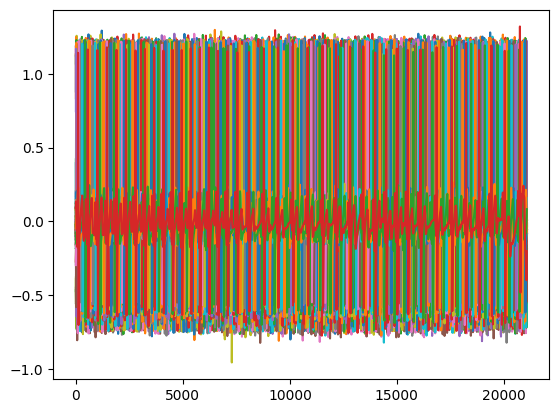

In [10]:
r_peaks = []
for idx, segment in tqdm(segments_df.iterrows()):
    # np.set_printoptions(threshold=len(segment) / 100)
    # print(f"Values for segment {idx}: {segment.values}")
    segment.plot.line()
    info = nk.ecg_findpeaks(segment, sampling_rate=ecg_sampling_rate)
    segment_r_peaks = {
        f"Segment {idx}": info['ECG_R_Peaks']
    }
    r_peaks.append(segment_r_peaks)

r_peaks

In [11]:
import warnings
warnings.filterwarnings('ignore')
hrv_stats = []
for r_peaks_idx in range(len(r_peaks)):
    r_peak = r_peaks[r_peaks_idx]
    for segment_name, r_peak_values in r_peak.items():
        hrv_segment_stats = nk.hrv(r_peak_values, ecg_sampling_rate)
        collect_hrv_stats = {
            f'HRV Stats @ {segment_name}': hrv_segment_stats
        }
        if r_peaks_idx < 3:
            print(f"{segment_name}: {r_peak_values}")
            print(f"\tstats: {hrv_segment_stats.to_dict()}\n")
        hrv_stats.append(hrv_segment_stats)

Segment 0: [  433   965  1518  2134  2750  3312  3869  4411  4904  5395  5889  6373
  6854  7360  7937  8551  9133  9794 10442 11050 11660 12280 12869 13405
 13906 14376 14834 15319 15824 16392 17094 17764 18361 18964 19493 19998
 20513]
	stats: {'HRV_MeanNN': {0: 796.825396825397}, 'HRV_SDNN': {0: 90.17321272329686}, 'HRV_SDANN1': {0: nan}, 'HRV_SDNNI1': {0: nan}, 'HRV_SDANN2': {0: nan}, 'HRV_SDNNI2': {0: nan}, 'HRV_SDANN5': {0: nan}, 'HRV_SDNNI5': {0: nan}, 'HRV_RMSSD': {0: 62.95308077456376}, 'HRV_SDSD': {0: 63.868272513996665}, 'HRV_CVNN': {0: 0.11316558568859962}, 'HRV_CVSD': {0: 0.07900486232664375}, 'HRV_MedianNN': {0: 792.8571428571429}, 'HRV_MadNN': {0: 113.31299999999993}, 'HRV_MCVNN': {0: 0.1429172972972972}, 'HRV_IQRNN': {0: 149.28571428571422}, 'HRV_SDRMSSD': {0: 1.432387606989544}, 'HRV_Prc20NN': {0: 705.7142857142858}, 'HRV_Prc80NN': {0: 877.1428571428571}, 'HRV_pNN50': {0: 33.33333333333333}, 'HRV_pNN20': {0: 63.888888888888886}, 'HRV_MinNN': {0: 654.2857142857142}, 'HR

In [12]:
segment_stats_df = pd.concat(hrv_stats)
segment_stats_df.reset_index(inplace=True)
segment_stats_df

,index,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,...,HRV_SampEn,HRV_ShanEn,HRV_FuzzyEn,HRV_MSEn,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC
0,0,796.825397,90.173213,NaN,NaN,NaN,NaN,NaN,NaN,62.953081,...,1.386294,5.058814,1.194704,0.000000,0.000000,0.00000,1.761447,1.567902,2.173417,1.005263
1,0,753.984962,77.663876,NaN,NaN,NaN,NaN,NaN,NaN,41.185547,...,2.197225,5.090033,0.965356,0.000000,0.000000,0.00000,1.793356,1.702745,1.928243,0.552413
2,0,864.242424,104.928599,NaN,NaN,NaN,NaN,NaN,NaN,65.889228,...,0.887303,5.044394,0.912039,0.000000,0.000000,0.00000,1.722494,1.635247,1.636326,0.764302
3,0,826.979592,124.734422,NaN,NaN,NaN,NaN,NaN,NaN,99.384057,...,0.980829,4.957854,0.961549,0.000000,0.000000,0.00000,1.400945,1.602764,2.428105,0.732755
4,0,893.883929,134.491574,NaN,NaN,NaN,NaN,NaN,NaN,105.675980,...,1.945910,4.875000,1.375253,0.000000,0.000000,0.00000,2.003920,1.812511,1.962972,0.937500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,0,868.354978,79.838901,NaN,NaN,NaN,NaN,NaN,NaN,84.658678,...,2.079442,4.923182,1.538913,0.000000,0.000000,0.00000,1.797831,1.816716,3.269665,1.222883
170,0,942.714286,81.633870,NaN,NaN,NaN,NaN,NaN,NaN,64.313076,...,1.098612,4.773557,1.333608,0.000000,0.000000,0.00000,1.724561,1.688900,2.238618,1.144941
171,0,929.047619,104.076200,NaN,NaN,NaN,NaN,NaN,NaN,98.116678,...,1.704748,4.840224,1.328496,0.000000,0.000000,0.00000,1.680274,1.976626,3.080472,0.981378
172,0,804.761905,115.783552,NaN,NaN,NaN,NaN,NaN,NaN,57.492299,...,1.321756,4.947703,0.841188,0.000000,0.000000,0.00000,1.412440,1.543275,1.635345,0.861654


<Axes: >

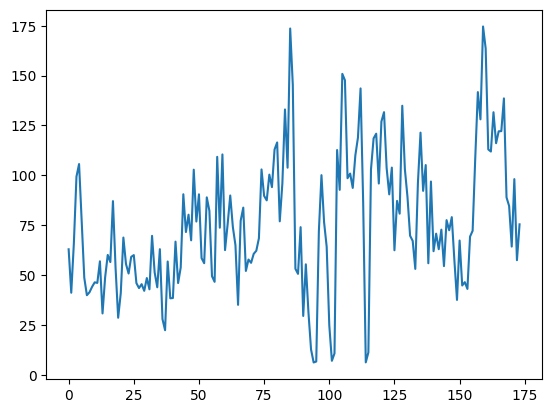

In [13]:
rmssd_series = segment_stats_df.loc[:, 'HRV_RMSSD']
rmssd_series.plot.line()

## Follow-Up

> - Be sure to see TODOs

1. What do we gather from this subject?
2. Is there anything to flag?
3. 'RMSSD_ms': np.float64(698.4470516017469)
    - Why?
    - Good/Bad?
4. 'HF': np.float64(0.04114562090390898), why?
    - Why?
    - Good/Bad?
5. RMSSD_ms and HF considered jointly
    - If one is good and other bad? Vice versa
    - If both are good? Both are bad?

### 1. What do we gather from this subject?

> - R-peaks (aka heartbeats in green).


In [14]:
# Could say something based on the avg of the window of 60 secs or take last

# Choose sampling rate and adjustable
# 